In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import joblib
from src.data.load_data import load_jobs
from src.data.preprocess import clean_text
from src.models.clustering import train_clustering, find_best_k, get_skill_gap

In [2]:
print("⏳ Loading saved data...")
vectorizer  = joblib.load('../models/tfidf_vectorizer.pkl')
job_matrix  = joblib.load('../models/job_matrix.pkl')
jobs        = joblib.load('../models/jobs_df.pkl')
print("✅ Loaded!", jobs.shape)

⏳ Loading saved data...
✅ Loaded! (50000, 6)


⏳ Finding best k... (takes 2-3 mins)
  k=3 done
  k=4 done
  k=5 done
  k=6 done
  k=7 done
  k=8 done
  k=9 done
  k=10 done
  k=11 done


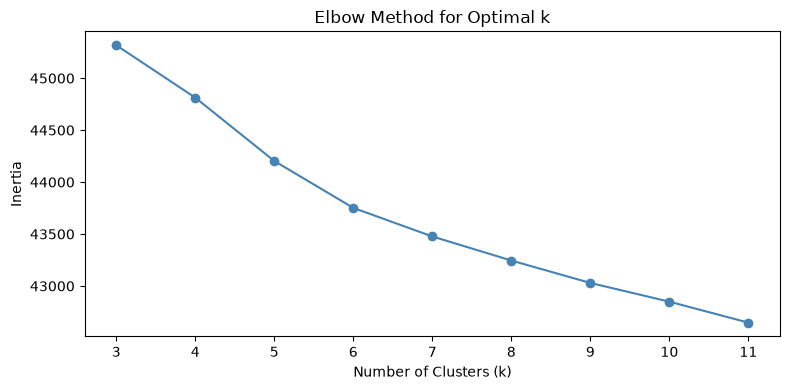

✅ Elbow plot saved!


In [5]:
import os
from sklearn.cluster import KMeans

os.makedirs('../reports/figures', exist_ok=True)
print("⏳ Finding best k... (takes 2-3 mins)")

inertias = []
k_range = range(3, 12)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(job_matrix)
    inertias.append(km.inertia_)
    print(f"  k={k} done")

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), inertias, marker="o", color="steelblue")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.tight_layout()
plt.savefig('../reports/figures/elbow_plot.png')
plt.show()
print("✅ Elbow plot saved!")

In [6]:
print("⏳ Training KMeans with k=8...")
km = train_clustering(job_matrix, n_clusters=8)
jobs['cluster'] = km.labels_
print("✅ Clustering done!")
print(jobs['cluster'].value_counts())

⏳ Training KMeans with k=8...
✅ Clustering done!
cluster
6    13514
1    12395
5     8682
7     5299
4     5253
3     2427
0     1393
2     1037
Name: count, dtype: int64


In [7]:
print("⏳ Calculating silhouette score...")
score = silhouette_score(job_matrix, km.labels_, sample_size=5000)
print(f"✅ Silhouette Score: {score:.4f}")
print("(Score closer to 1.0 is better)")

⏳ Calculating silhouette score...
✅ Silhouette Score: 0.0341
(Score closer to 1.0 is better)


⏳ Reducing dimensions with PCA...


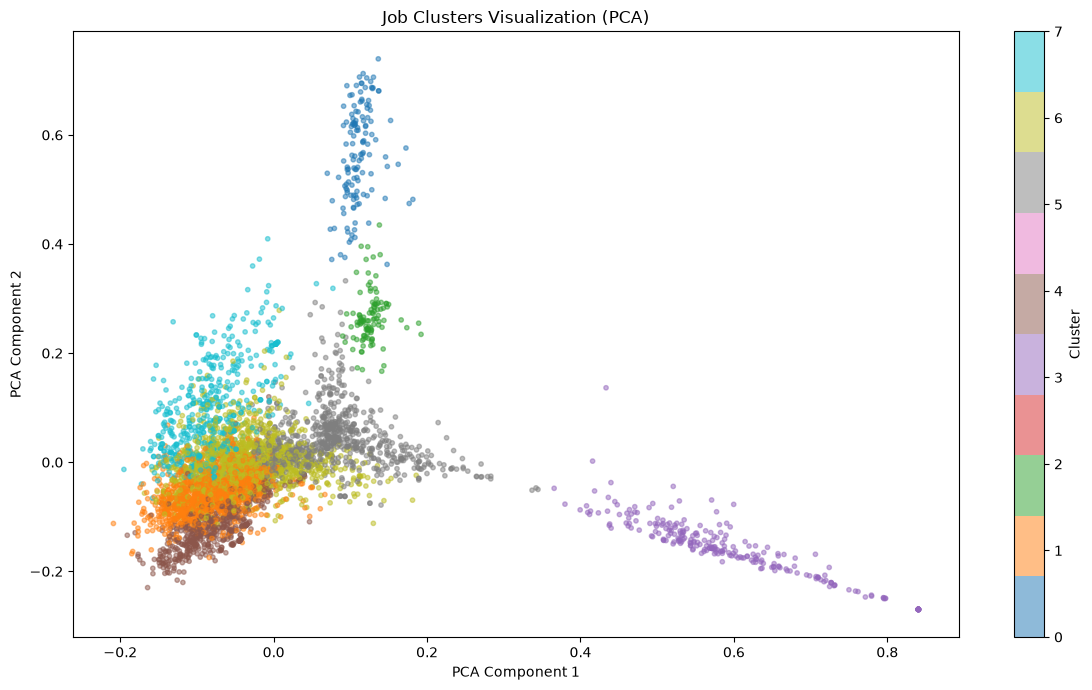

✅ Plot saved!


In [8]:
print("⏳ Reducing dimensions with PCA...")
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(job_matrix.toarray()[:5000])
labels = km.labels_[:5000]

plt.figure(figsize=(12, 7))
scatter = plt.scatter(coords[:, 0], coords[:, 1], 
                      c=labels, cmap='tab10', alpha=0.5, s=10)
plt.colorbar(scatter, label='Cluster')
plt.title('Job Clusters Visualization (PCA)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.tight_layout()
plt.savefig('../reports/figures/job_clusters_pca.png')
plt.show()
print("✅ Plot saved!")

In [9]:
for cluster_id in range(8):
    cluster_jobs = jobs[jobs['cluster'] == cluster_id]
    top_titles = cluster_jobs['title'].value_counts().head(3)
    print(f"\n🔵 Cluster {cluster_id} ({len(cluster_jobs)} jobs):")
    print(top_titles.to_string())


🔵 Cluster 0 (1393 jobs):
title
Business Development Executive    34
Sales Executive                   28
Business Development Manager      26

🔵 Cluster 1 (12395 jobs):
title
Receptionist                       60
Customer Service Representative    47
Maintenance Technician             47

🔵 Cluster 2 (1037 jobs):
title
Customer Care Executive       7
Customer Support Executive    5
Customer Service Executive    5

🔵 Cluster 3 (2427 jobs):
title
PHP Developer        26
Java Developer       22
Software Engineer    21

🔵 Cluster 4 (5253 jobs):
title
Registered Nurse                73
Registered Nurse - RN - LTAC    50
Patient Care Technician         45

🔵 Cluster 5 (8682 jobs):
title
 Graphic Designer    37
Staff Accountant     33
Senior Accountant    29

🔵 Cluster 6 (13514 jobs):
title
Project Manager      129
Senior Accountant     51
Software Engineer     51

🔵 Cluster 7 (5299 jobs):
title
Sales Manager                      137
Retail Sales Associate              72
Customer Service Re

In [10]:
from src.data.load_data import load_resumes

resumes = load_resumes()
sample_resume = resumes['Resume'].iloc[0]
clean = clean_text(sample_resume)
category = resumes['Category'].iloc[0]

print(f"📄 Resume Category: {category}")
print("-" * 50)

gap = get_skill_gap(clean, jobs)
print("\n✅ Skills you HAVE:")
for s in gap['skills_you_have']:
    print(f"  • {s}")

print("\n⚠️ Skills to ADD:")
for s in gap['skills_to_learn']:
    print(f"  • {s}")

📄 Resume Category: Data Science
--------------------------------------------------

✅ Skills you HAVE:

⚠️ Skills to ADD:
  • sexual orientation
  • people skills
  • color
  • religion
  • national origin
  • networking
  • fundraising
  • age
  • community outreach
  • csr / volunteer coordination


In [11]:
joblib.dump(km, '../models/kmeans_model.pkl')
joblib.dump(jobs, '../models/jobs_df.pkl')
print("✅ Clustering model saved!")

✅ Clustering model saved!
